# Malha simplex-lattice

Considere $M$ objetivos e um inteiro $p\ge 0$. Os pontos são

$$
\Big\{\; \tfrac{1}{p}\,(k_1,\dots,k_M)\;:\; k_i\in\mathbb{Z}_{\ge 0},\; \sum_{i=1}^M k_i=p \;\Big\}.
$$

O número total de pontos é o número de soluções inteiras não-negativas de $\sum k_i=p$:

$$
\;N(M,p)=\binom{p+M-1}{M-1}
$$

In [1]:
import numpy as np

def generate_reference_points(M, p):
    def generate_recursive(
        points: list[list[float]], # lista onde acumulamos todos os pontos gerados
        num_objs: int, # número de objetivos, dimensão do espaço objetivo
        left: int, # quanto ainda falta distribuir (em divisões inteiras)
        total: int, # número total de divisões p, usado para normalizar
        depth: int, # profundidade atual da recursão (qual coordenada estamos definindo)
        current_point: list[float] # vetor parcial já construído
        )->np.ndarray:
        if depth == num_objs - 1:
            current_point.append(left / total)
            points.append(current_point.copy())
            print(f'new point: {current_point}')
            current_point.pop()
        else:
            for i in range(left + 1):
                current_point.append(i / total)
                generate_recursive(points, num_objs, left - i, total, depth + 1, current_point)
                current_point.pop()
    points = []
    generate_recursive(points, M, p, p, 0, [])
    return np.array(points)

In [3]:
M = 2
divisions = 6
_ = generate_reference_points(M, divisions)

new point: [0.0, 1.0]
new point: [0.16666666666666666, 0.8333333333333334]
new point: [0.3333333333333333, 0.6666666666666666]
new point: [0.5, 0.5]
new point: [0.6666666666666666, 0.3333333333333333]
new point: [0.8333333333333334, 0.16666666666666666]
new point: [1.0, 0.0]


In [4]:
M = 3
divisions = 6
_ = generate_reference_points(M, divisions)

new point: [0.0, 0.0, 1.0]
new point: [0.0, 0.16666666666666666, 0.8333333333333334]
new point: [0.0, 0.3333333333333333, 0.6666666666666666]
new point: [0.0, 0.5, 0.5]
new point: [0.0, 0.6666666666666666, 0.3333333333333333]
new point: [0.0, 0.8333333333333334, 0.16666666666666666]
new point: [0.0, 1.0, 0.0]
new point: [0.16666666666666666, 0.0, 0.8333333333333334]
new point: [0.16666666666666666, 0.16666666666666666, 0.6666666666666666]
new point: [0.16666666666666666, 0.3333333333333333, 0.5]
new point: [0.16666666666666666, 0.5, 0.3333333333333333]
new point: [0.16666666666666666, 0.6666666666666666, 0.16666666666666666]
new point: [0.16666666666666666, 0.8333333333333334, 0.0]
new point: [0.3333333333333333, 0.0, 0.6666666666666666]
new point: [0.3333333333333333, 0.16666666666666666, 0.5]
new point: [0.3333333333333333, 0.3333333333333333, 0.3333333333333333]
new point: [0.3333333333333333, 0.5, 0.16666666666666666]
new point: [0.3333333333333333, 0.6666666666666666, 0.0]
new poi

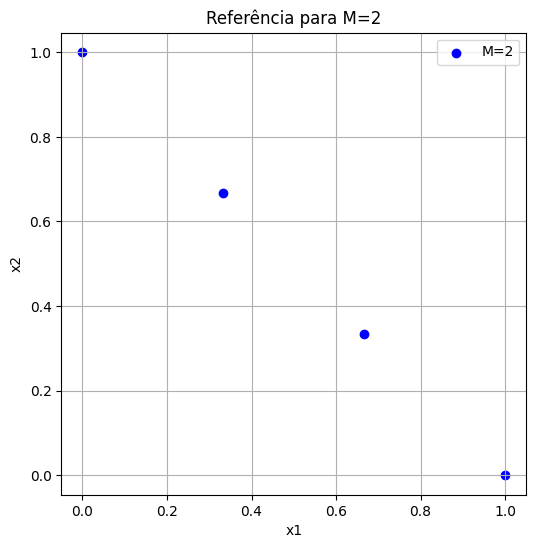

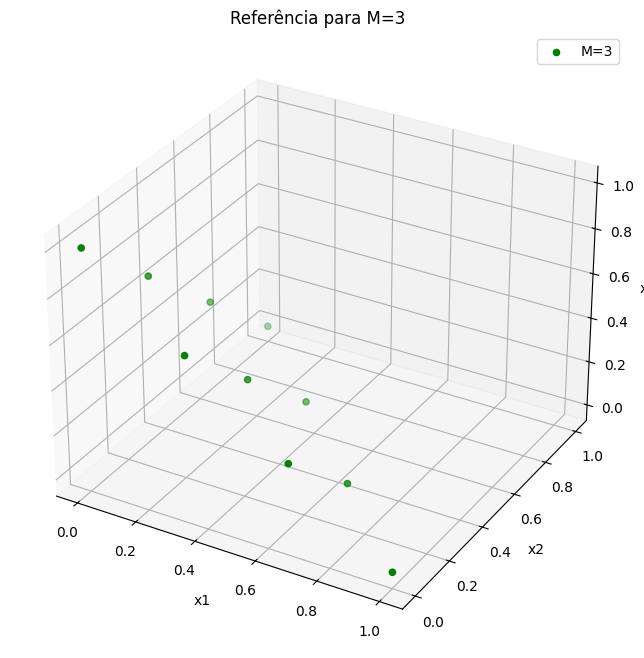

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Função fornecida
def generate_reference_points(M, p):
    def generate_recursive(points, num_objs, left, total, depth, current_point):
        if depth == num_objs - 1:
            current_point.append(left / total)
            points.append(current_point.copy())
            current_point.pop()
        else:
            for i in range(left + 1):
                current_point.append(i / total)
                generate_recursive(points, num_objs, left - i, total, depth + 1, current_point)
                current_point.pop()
    points = []
    generate_recursive(points, M, p, p, 0, [])
    return np.array(points)

# Divisões
p = 3 

# Caso M=2
points_2d = generate_reference_points(2, p)
plt.figure(figsize=(6, 6))
plt.scatter(points_2d[:, 0], points_2d[:, 1], color='blue', label='M=2')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Referência para M=2')
plt.grid(True)
plt.axis('equal')
plt.legend()
plt.show()

# Caso M=3
points_3d = generate_reference_points(3, p)
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points_3d[:, 0], points_3d[:, 1], points_3d[:, 2], color='green', label='M=3')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('x3')
ax.set_title('Referência para M=3')
ax.legend()
plt.show()

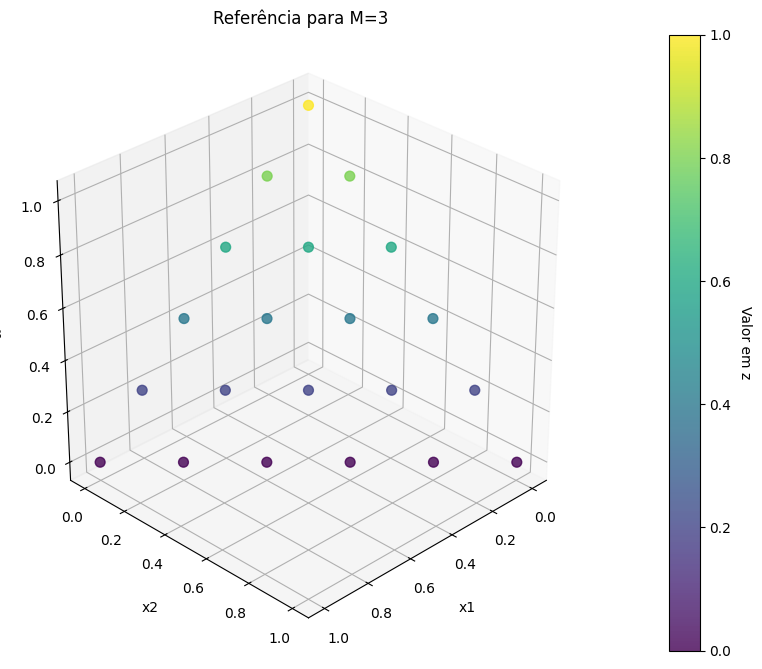

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Função fornecida
def generate_reference_points(M, p):
    def generate_recursive(points, num_objs, left, total, depth, current_point):
        if depth == num_objs - 1:
            current_point.append(left / total)
            points.append(current_point.copy())
            current_point.pop()
        else:
            for i in range(left + 1):
                current_point.append(i / total)
                generate_recursive(points, num_objs, left - i, total, depth + 1, current_point)
                current_point.pop()
    points = []
    generate_recursive(points, M, p, p, 0, [])
    return np.array(points)

# Divisões
p = 5 

# Caso M=3
points_3d = generate_reference_points(3, p)

# Melhor visualização 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Ajustes de ponto e cor
sc = ax.scatter(
    points_3d[:, 0], 
    points_3d[:, 1], 
    points_3d[:, 2], 
    c=points_3d[:, 2],  # Cor varia com o eixo z
    cmap='viridis',     # Mapa de cores para melhor visual
    s=50,               # Tamanho dos pontos
    alpha=0.8           # Transparência para suavidade
)

# Adicionar barra de cores
cbar = fig.colorbar(sc, ax=ax, pad=0.1)
cbar.set_label('Valor em z', rotation=270, labelpad=15)

# Melhorar rótulos e título
ax.set_xlabel('x1', labelpad=10)
ax.set_ylabel('x2', labelpad=10)
ax.set_zlabel('x3', labelpad=10)
ax.set_title('Referência para M=3', pad=20)

# Ajustar ângulo de visualização
ax.view_init(elev=30, azim=45)

# Adicionar grid e ajustar limites
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_box_aspect([1, 1, 1])  # Proporção do box 3D
plt.show()


In [9]:
import math

def num_reference_points(M: int, div: int) -> int:
    """
    Retorna a quantidade de pontos de referência gerados
    para M objetivos e 'div' divisões (Das-Dennis mesh).
    
    Fórmula: C(M+div-1, M-1)
    """
    return math.comb(M + div - 1, M - 1)

# Exemplos de uso
print(num_reference_points(2, 3))  
print(num_reference_points(3, 3))   
print(num_reference_points(6, 21))


4
10
65780
